# **Time Series Forecasting: Linear Regression & Extreme Learning Machines (ELM)**

A Time Series forecasting project exploring Linear Predictors and Non-Linear mappings (ELM)

---

### **Context & Dataset: The Mackey-Glass Time Series**

The objective of this project is to model and predict future values of the **Mackey-Glass time series**. This well-known series is associated with a continuous, non-linear, and chaotic dynamical system. Originally proposed to model the physiological control of blood cell production, the equation exhibits highly complex, chaotic behavior for certain parameters, making it a standard benchmark for evaluating time-series prediction algorithms.

The prediction task consists of estimating the future value of the series $y(n) = x(n+L)$ (where $L$ is the prediction horizon) given a vector of $K$ past observations: $x(n) = [x(n-L), ..., x(n-L-K+1)]^T$.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

## Part 1: Linear Predictor for Time Series Prediction

### Data Partitioning Strategy

The dataset is partitioned into **training**, **validation**, and **test** sets. The test set comprises the final 750 samples. 
A strict "holdout" cross-validation strategy is employed, allocating 80% of the remaining data for training and 20% for validation. Crucially, the validation set is contiguous and chronologically follows the training set. 
Since the data represents a time series, random data splitting techniques (such as standard K-Fold) are avoided to prevent data leakage from the future into the past and to preserve the temporal dynamics.

In [25]:
# Load the Mackey-Glass time series dataset
df = pd.read_csv("mackeyglass.csv", sep=",")

# Train/Validation/Test split
train = df[:3400]
valid = df[3400:-750].reset_index(drop=True)
test = df[-750:].reset_index(drop=True)

print(f"Train size: {len(train)}")
print(f"Validation size: {len(valid)}")
print(f"Test size: {len(test)}")

Train size: 3400
Validation size: 850
Test size: 750


### Training and Hyperparameter Tuning

The input features and target outputs are organized as a function of the number of past samples (the hyperparameter `K`). 
A simple linear predictor is trained via Least Squares on the training set. Subsequently, predictions are generated for the validation set. By calculating the Root Mean Squared Error (RMSE) across a range of `K` values, the optimal input vector size for predicting the time series is determined.

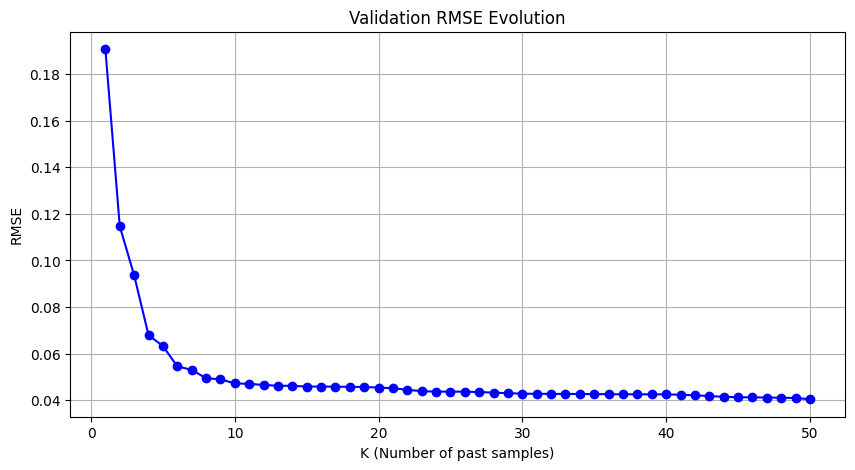


Best predictor version: K = 50
Validation error for the best predictor: RMSE = 0.0405


In [26]:
L = 7  # prediction horizon
RMSE = []  # list to store the RMSE for each generated predictor

for k in range(1, 51):
    x_train, y_train = [], []
    
    # Split the training set into input (x) and output (y)
    for i in range(len(train) - L - k + 1):
        x_train.append(train.loc[i : i+k-1, 'p'])  # input vector of size k
        y_train.append(train.loc[i+L+k-1, 'p'])    # target value L steps ahead

    x_train = np.array(x_train)
    x_train = np.hstack((np.ones((len(x_train), 1)), x_train))  # add bias

    y_train = np.array(y_train)[:, np.newaxis]

    # Create and train the linear regression model
    regr = linear_model.LinearRegression()
    regr.fit(x_train, y_train)

    x_valid, y_valid = [], []
    
    # Prepare the validation set
    for i in range(len(valid)):
        y_valid.append(valid.loc[i, 'p'])
        if i >= L + k - 1:
            x_valid.append(np.array(valid.iloc[i-(L+k-1) : i-(L-1), 1]))
        else:
            # Handle transition between train and validation sets for inputs
            if len(train.iloc[i-(L+k-1):, 1]) > k:
                x_valid.append(np.array(train.iloc[i-(L+k-1) : i-(L-1), 1]))
            elif len(train.iloc[i-(L+k-1):, 1]) == k:
                x_valid.append(np.array(train.iloc[i-(L+k-1):, 1]))
            else:
                a = train.iloc[i-(L+k-1):, 1]
                b = valid.iloc[:k-len(a), 1]
                c = pd.concat([a, b], ignore_index=True)
                x_valid.append(np.array(c))

    x_valid = np.array(x_valid)
    x_valid = np.hstack((np.ones((len(x_valid), 1)), x_valid))  # add bias

    y_valid = np.array(y_valid)[:, np.newaxis]

    # Predictions on validation set
    y_pred_valid = regr.predict(x_valid)

    # Calculate and store RMSE
    RMSE.append(np.sqrt(mean_squared_error(y_valid, y_pred_valid)))

# The best hyperparameter K is the one that minimizes the RMSE
k_optimal = RMSE.index(min(RMSE)) + 1

plt.figure(figsize=(10, 5))
plt.plot(range(1, 51), RMSE, marker='o', linestyle='-', color='b')
plt.title('Validation RMSE Evolution')
plt.xlabel('K (Number of past samples)')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

print(f'\nBest predictor version: K = {k_optimal}')
print(f'Validation error for the best predictor: RMSE = {min(RMSE):.4f}')

We can also visualize the performance of this optimal predictor on the validation set:

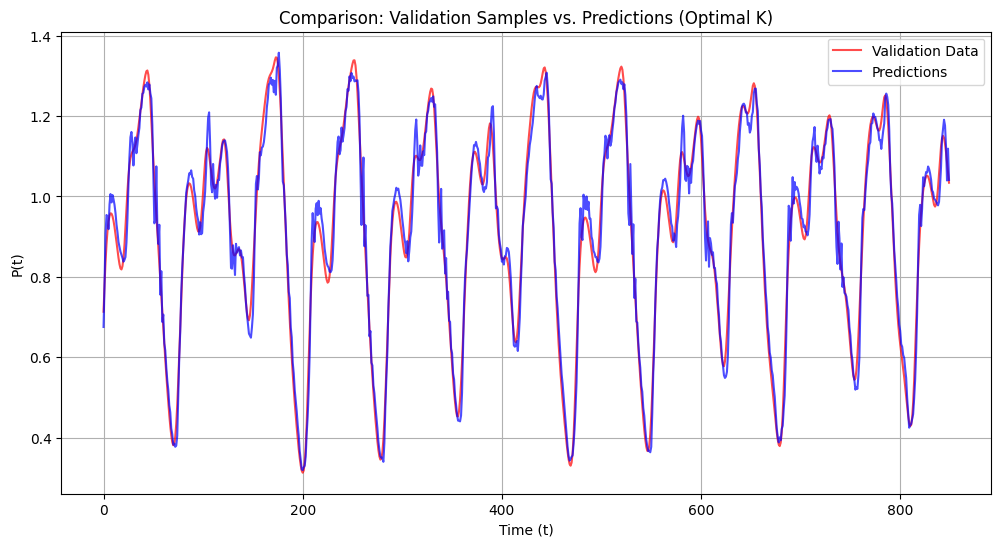

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(y_valid, color="red", label='Validation Data', alpha=0.7)
plt.plot(y_pred_valid, color="blue", label='Predictions', alpha=0.7)
plt.title('Comparison: Validation Samples vs. Predictions (Optimal K)')
plt.xlabel('Time (t)')
plt.ylabel('P(t)')
plt.legend()
plt.grid(True)
plt.show()

### Final Linear Model

With the optimal number of past samples (`k_optimal`) identified, the final linear model is retrained using the exact closed-form solution of Ordinary Least Squares (OLS) equations.

In [28]:
# Prepare train data with the optimal K
x_train, y_train = [], []
for i in range(len(train) - L - k_optimal + 1):
    x_train.append(train.loc[i : i+k_optimal-1, 'p'])
    y_train.append(train.loc[i+L+k_optimal-1, 'p'])

x_train = np.array(x_train)
x_train = np.hstack((np.ones((len(x_train), 1)), x_train))
y_train = np.array(y_train)[:, np.newaxis]

# Train the optimal model using Least Squares closed-form solution
w_train_optimal = np.matmul(np.matmul(np.linalg.inv(np.matmul(np.transpose(x_train), x_train)), np.transpose(x_train)), y_train)

### Evaluation on Unseen Data

The trained optimal linear predictor is finally applied to the independent **test set** to assess its generalization capability and calculate the final predictive RMSE.

In [29]:
# Prepare test data
x_test, y_test = [], []
for i in range(len(test)):
    y_test.append(test.loc[i, 'p'])
    if i >= L + k_optimal - 1:
        x_test.append(np.array(test.iloc[i-(L+k_optimal-1) : i-(L-1), 1]))
    else:
        if len(valid.iloc[i-(L+k_optimal-1):, 1]) > k_optimal:
            x_test.append(np.array(valid.iloc[i-(L+k_optimal-1) : i-(L-1), 1]))
        elif len(valid.iloc[i-(L+k_optimal-1):, 1]) == k_optimal:
            x_test.append(np.array(valid.iloc[i-(L+k_optimal-1):, 1]))
        else:
            a = valid.iloc[i-(L+k_optimal-1):, 1]
            b = test.iloc[:k_optimal-len(a), 1]
            c = pd.concat([a, b], ignore_index=True)
            x_test.append(np.array(c))

x_test = np.array(x_test)
x_test = np.hstack((np.ones((len(x_test), 1)), x_test))
y_test = np.array(y_test)[:, np.newaxis]

# Make predictions on the test set using the closed-form weights
y_pred_test = regr.predict(x_test)

# Calculate and print the RMSE for the test set
RMSE_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f'Test Set Error: RMSE = {RMSE_test:.4f}')

Test Set Error: RMSE = 0.0413


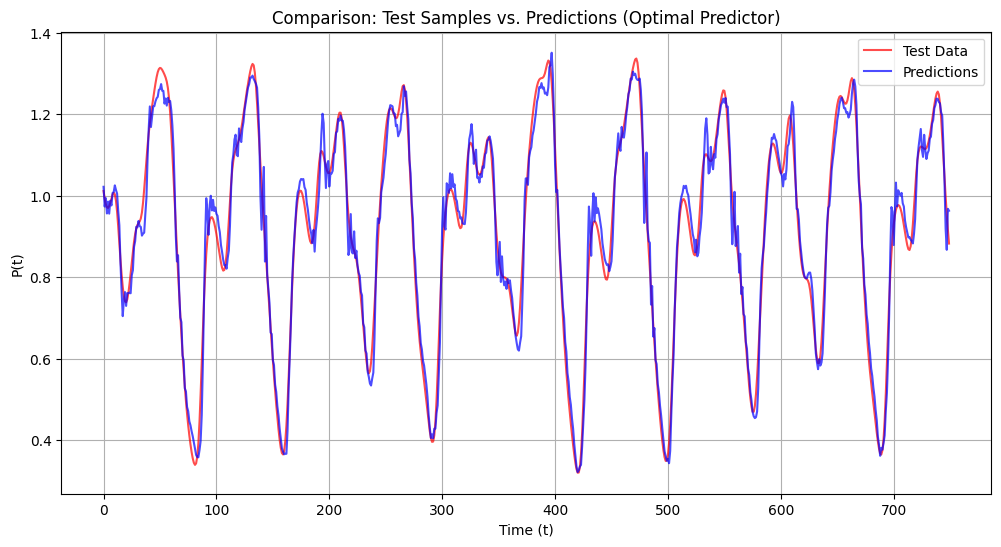

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.flatten(), color="red", label='Test Data', alpha=0.7)
plt.plot(y_pred_test.flatten(), color="blue", label='Predictions', alpha=0.7)
plt.title('Comparison: Test Samples vs. Predictions (Optimal Predictor)')
plt.xlabel('Time (t)')
plt.ylabel('P(t)')
plt.legend()
plt.grid(True)
plt.show()


## Part 2: Extreme Learning Machine (ELM) & Ridge Regression

To capture the non-linear chaotic dynamics of the Mackey-Glass series more effectively, an Extreme Learning Machine (ELM) architecture is introduced. 

In this approach, the original input features are projected into a higher-dimensional space using non-linear mappings (Hyperbolic Tangent). Specifically, $V$ new attributes are generated using randomly initialized weight vectors $w'$.

$$x'(n) = \tanh(w'^T_kx(n))$$

To prevent overfitting in this expanded feature space, the output layer weights are computed using **Ridge Regression** (L2 Regularization), defined by the closed-form equation:

$$w=(\phi^T\phi+\lambda I)^{-1}\phi^Ty$$
Where $\lambda$ controls the regularization strength.

### Data Normalization
Due to the nature of the $\tanh$ activation function, data normalization (zero mean, unit variance) is applied before partitioning the dataset to maintain numerical stability during the non-linear transformations.

In [31]:
df = pd.read_csv("mackeyglass.csv", sep=",")

# Normalization
mean_val = np.mean(df['p'])
std_val = np.std(df['p'])
df['p'] = (df['p'] - mean_val) / std_val

train = df[:3400]
valid = df[3400:-750].reset_index(drop=True)
test = df[-750:].reset_index(drop=True)

### Feature Engineering

Input and output pairs are structured for the training and validation phases. Based on insights from Part 1, the number of input delays is fixed at **`K = 10`**.

In [45]:
L = 7
k = 10
min_exp_coef = -15
max_exp_coef = 5
base_coef = 10

# Prepare Train Set
x_train, y_train = [], []
for i in range(len(train) - L - k + 1):
    x_train.append(train.loc[i : i+k-1, 'p'])
    y_train.append(train.loc[i+L+k-1, 'p'])

x_train = np.array(x_train)
y_train = np.array(y_train)[:, np.newaxis]

# Prepare Validation Set
x_valid, y_valid = [], []
for i in range(len(valid)):
    y_valid.append(valid.loc[i, 'p'])
    if i >= L + k - 1:
        x_valid.append(np.array(valid.iloc[i-(L+k-1) : i-(L-1), 1]))
    else:
        if len(train.iloc[i-(L+k-1):, 1]) > k:
            x_valid.append(np.array(train.iloc[i-(L+k-1) : i-(L-1), 1]))
        elif len(train.iloc[i-(L+k-1):, 1]) == k:
            x_valid.append(np.array(train.iloc[i-(L+k-1):, 1]))
        else:
            a = train.iloc[i-(L+k-1):, 1]
            b = valid.iloc[:k-len(a), 1]
            c = pd.concat([a, b], ignore_index=True)
            x_valid.append(np.array(c))

x_valid = np.array(x_valid)
y_valid = np.array(y_valid)[:, np.newaxis]

### Hyperparameter Grid Search: $V$ and $\lambda$

A comprehensive grid search is executed to identify the optimal model complexity and regularization strength. 
The number of hidden neurons/attributes ($V$) is evaluated from 1 to 1000, and for each architecture size, a logarithmic range of the regularization parameter ($\lambda$) is tested. The validation RMSE is stored to determine the optimal configuration.

In [46]:
RMSE_Vcoefr = []

# Warning: This cell may take some time to execute (searching V from 1 to 1000)
for V in range(1, 1001, 10):
    w = np.random.uniform(-0.1, 0.1, size=(V, k))  # Random weight vectors
    I = np.identity(V + 1)
    I[0, 0] = 0  # Do not regularize the bias term
    
    # Apply non-linear transformation (Hyperbolic Tangent) to Train
    x_train_mod = np.tanh(np.dot(w, np.transpose(x_train)))
    x_train_mod = np.vstack((np.ones((1, x_train_mod.shape[1])), x_train_mod))  # add bias
    x_train_mod = np.transpose(x_train_mod)
    
    # Apply non-linear transformation to Validation
    x_valid_mod = np.tanh(np.dot(w, np.transpose(x_valid)))
    x_valid_mod = np.vstack((np.ones((1, x_valid_mod.shape[1])), x_valid_mod))  # add bias
    
    RMSE_coefr = []
    # Iterate over different lambda values (regularization coefficients)
    for coefr in np.logspace(min_exp_coef, max_exp_coef, num=max_exp_coef-min_exp_coef+1, base=base_coef):
        # Ridge Regression Training
        w_train = np.matmul(np.matmul(np.linalg.inv(np.matmul(np.transpose(x_train_mod), x_train_mod) + coefr*I), np.transpose(x_train_mod)), y_train)
        
        # Validation Prediction
        y_pred = np.matmul(np.transpose(w_train), x_valid_mod)
        
        # Denormalize outputs to calculate RMSE in original scale
        y_pred_un_norm = (std_val * y_pred) + mean_val
        y_valid_un_norm = (std_val * y_valid) + mean_val
        
        RMSE_coefr.append(np.sqrt(mean_squared_error(y_valid_un_norm, np.transpose(y_pred_un_norm))))
        
    RMSE_Vcoefr.append(RMSE_coefr)

RMSE_Vcoefr = np.array(RMSE_Vcoefr)

### Optimal Network Architecture ($V$)
The plot below illustrates the lowest validation RMSE achieved for each network size ($V$). This visualizes the trade-off between model capacity and prediction error.

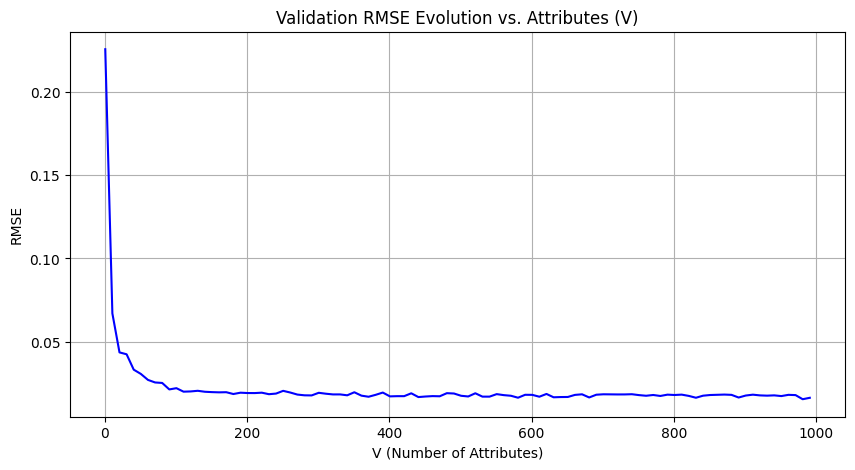

Best predictor version: V = 981
Validation error for the best predictor: RMSE = 0.0155


In [53]:
rmse_min_for_each_V = np.min(RMSE_Vcoefr, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 1001, 10), rmse_min_for_each_V, color='b')
plt.title('Validation RMSE Evolution vs. Attributes (V)')
plt.xlabel('V (Number of Attributes)')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

best_V_idx = np.argmin(rmse_min_for_each_V)
print(f'Best predictor version: V = {best_V_idx*10 + 1}')
print(f'Validation error for the best predictor: RMSE = {rmse_min_for_each_V[best_V_idx]:.4f}')

In [56]:
len(rmse_min_for_each_V)

100

In [54]:
best_V_idx

np.int64(98)

### Optimal Regularization ($\lambda$)
For each specific network size ($V$), a corresponding optimal regularization parameter ($\lambda$) is identified to prevent overfitting. The relationship is plotted below.

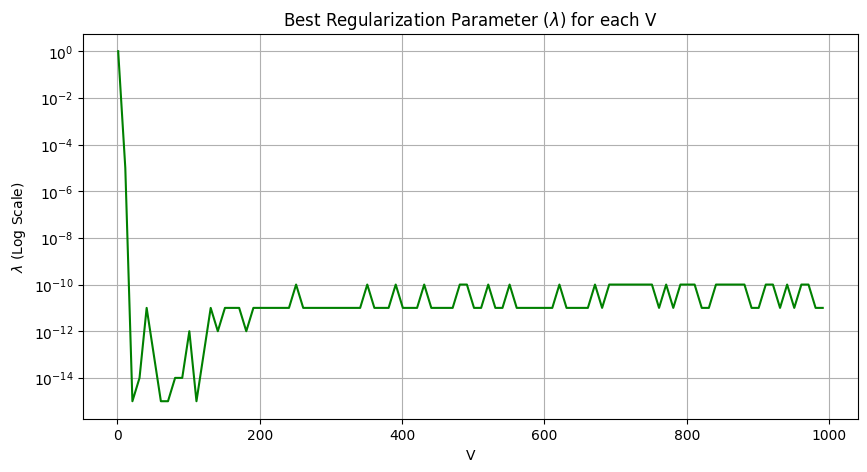

In [51]:
seq_coef = []
for i in range(len(RMSE_Vcoefr)):
    indice = np.where(RMSE_Vcoefr[i] == np.amin(RMSE_Vcoefr, axis=1)[i]) 
    # armazena o melhor coeficiente de regularização para cada valor de V 
    seq_coef.append(base_coef**(min_exp_coef+int(indice[0][0])))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 1001, 10), seq_coef, color='g')
plt.yscale('log')
plt.title('Best Regularization Parameter ($\lambda$) for each V')
plt.xlabel('V')
plt.ylabel('$\lambda$ (Log Scale)')
plt.grid(True)
plt.show()

To visualize the impact of the regularization parameter, we can plot the RMSE evolution for a specific value of $V$ (e.g., $V = 981$).

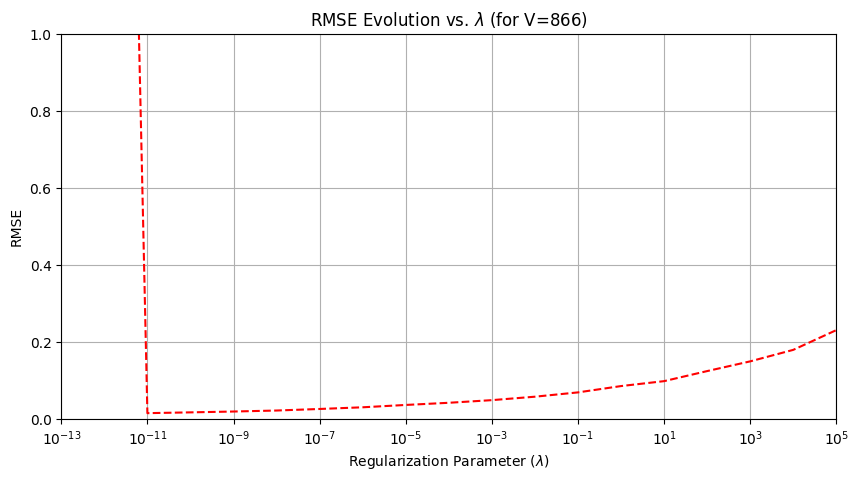

In [57]:
plt.figure(figsize=(10, 5))
plt.semilogx(np.logspace(min_exp_coef, max_exp_coef, num=max_exp_coef-min_exp_coef+1, base=base_coef), RMSE_Vcoefr[best_V_idx], 'r--')
plt.axis([1e-13, 1e5, 0, 1])
plt.title('RMSE Evolution vs. $\lambda$ (for V=866)')
plt.xlabel('Regularization Parameter ($\lambda$)')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

### Final ELM Evaluation

The global optimal hyperparameters ($V$ and $\lambda$) are extracted. The final ELM model is constructed, its weights are established via Ridge Regression on the training data, and its predictive performance is quantified on the **test set**.

In [70]:
# Find global minimum (V and lambda)
global_minimum = np.where(RMSE_Vcoefr==np.min(RMSE_Vcoefr)) # retorna as coordenadas do mínimo global (V,lambda)
V_best = global_minimum[0][0]*10 + 1 # o índice de V é igual a seu valor -1
lambd_best = base_coef**(min_exp_coef+int(global_minimum[1][0])) # converte o índice do lambda no seu valor correspondente, de acordo com a faixa de valores utilizado

print(f'Best Model: V = {V_best} | Regularization Parameter (lambda) = {lambd_best}')

Best Model: V = 981 | Regularization Parameter (lambda) = 1e-11


In [73]:
# Retrain Final Model with Optimal Parameters
w = np.random.uniform(-0.1, 0.1, size=(V_best, k))
x_train = []
y_train = []
for i in range(len(train)-L-k+1):
  x_train.append(train.loc[i:i+k-1, 'p'])
  y_train.append(train.loc[i+L+k-1, 'p'])

x_train = np.array(x_train)
x_train_mod = np.tanh(np.dot(w, np.transpose(x_train)))
x_train_mod = np.vstack((np.ones((1, x_train_mod.shape[1])), x_train_mod))
x_train_mod = np.transpose(x_train_mod)

y_train = np.array(y_train)
y_train = y_train[:,np.newaxis]

I = np.identity(V_best+1)
I[0,0] = 0
# Ridge Regression - treinamento do modelo
w_opt = np.matmul(np.matmul(np.linalg.inv(np.matmul(np.transpose(x_train_mod), x_train_mod) + lambd_best*I), np.transpose(x_train_mod)), y_train)

In [74]:
# Prepare Test Set
x_test, y_test = [], []
for i in range(len(test)):
    y_test.append(test.loc[i, 'p'])
    if i >= L + k - 1:
        x_test.append(np.array(test.iloc[i-(L+k-1) : i-(L-1), 1]))
    else:
        if len(valid.iloc[i-(L+k-1):, 1]) > k:
            x_test.append(np.array(valid.iloc[i-(L+k-1) : i-(L-1), 1]))
        elif len(valid.iloc[i-(L+k-1):, 1]) == k:
            x_test.append(np.array(valid.iloc[i-(L+k-1):, 1]))
        else:
            a = valid.iloc[i-(L+k-1):, 1]
            b = test.iloc[:k-len(a), 1]
            c = pd.concat([a, b], ignore_index=True)
            x_test.append(np.array(c))

x_test = np.array(x_test)
y_test = np.array(y_test)[:, np.newaxis]

# Predictions
x_test_mod = np.tanh(np.dot(w, np.transpose(x_test)))
x_test_mod = np.vstack((np.ones((1, x_test_mod.shape[1])), x_test_mod))

y_pred_test = np.matmul(np.transpose(w_opt), x_test_mod)

# Denormalize
y_pred_test_un_norm = (std_val * y_pred_test) + mean_val
y_test_un_norm = (std_val * y_test) + mean_val

# Test RMSE
RMSE_test = np.sqrt(mean_squared_error(y_test_un_norm, np.transpose(y_pred_test_un_norm)))
print(f'Test Set Error: RMSE = {RMSE_test:.4f}')

Test Set Error: RMSE = 0.0239


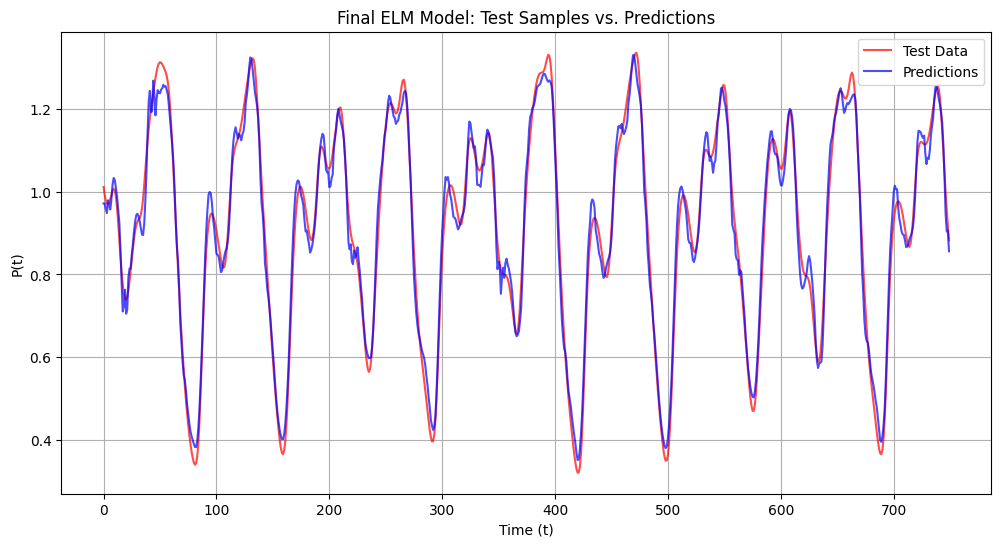

In [67]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_un_norm.flatten(), color="red", label='Test Data', alpha=0.7)
plt.plot(y_pred_test_un_norm.flatten(), color="blue", label='Predictions', alpha=0.7)
plt.title('Final ELM Model: Test Samples vs. Predictions')
plt.xlabel('Time (t)')
plt.ylabel('P(t)')
plt.legend()
plt.grid(True)
plt.show()
